# Notebook 02 — Categorical And Numeric Cleaning (Missingness, Outliers, Imputation)

This notebook performs categorical and numeric cleaning on the structurally cleaned dataset from Notebook 01.

We will perform:

1. Category Standardization
2. Clinical Normalization
3. Outlier Detection using Clinical Valid Ranges
4. Missingness & Diagnostic EDA
   - Flag
   - Diagnose
   - Impute(only if the diagnosis shows no systemic bias)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/interim/structural_cleaned_data.csv', parse_dates=['collection_date'])
clean_df = df
clean_df.head()

,patient_id,collection_date,location,pathogen,age,severity_score
0,202,2026-01-29,South East,Flu A,34,3.0
1,279,2026-01-07,South East,Influenza A,69,2.0
2,192,2026-01-05,North Central,Unknown,82,1.0
3,114,2026-01-22,North West,Flu A,29,5.0
4,206,2026-01-29,North West,Influenza A,70,5.0


In [3]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   patient_id       500 non-null    int64         
 1   collection_date  500 non-null    datetime64[ns]
 2   location         500 non-null    object        
 3   pathogen         500 non-null    object        
 4   age              500 non-null    int64         
 5   severity_score   355 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 23.6+ KB


### Identify Categorical Variables

In [4]:
cat_cols = clean_df.select_dtypes(include = ['object']).columns.tolist()
cat_cols

['location', 'pathogen']

### Categorical Missingness Audit

In [5]:
missing_counts = clean_df[cat_cols].isnull().sum()
missing_percentage = round((missing_counts/len(clean_df))*100, 2)

pd.DataFrame({
    'Missing Counts': missing_counts,
    'Missing %': missing_percentage
})

,Missing Counts,Missing %
location,0,0.0
pathogen,0,0.0


### Cleaning Each Categorical Variable
Category Standardization And Normalization

In [6]:
for col in cat_cols:
    col_lc = col.lower()

    if 'location' in col_lc:
        clean_df[col] = (
            clean_df[col]
            .astype(str)
            .str.lower()
            .str.strip()
            .replace({'nan': np.nan})
        )

    elif 'pathogen' in col_lc:
        clean_df[col] = (
            clean_df[col]
            .astype(str)
            .str.lower()
            .str.strip()
            .replace({
                'flu a': 'influenza a',
                'sars-cov-2': 'sars_cov_2',
                'sars cov 2': 'sars_cov_2',
                'unknown': 'unknown',
                'nan': np.nan
            })
        )
        
clean_df.head()

,patient_id,collection_date,location,pathogen,age,severity_score
0,202,2026-01-29,south east,influenza a,34,3.0
1,279,2026-01-07,south east,influenza a,69,2.0
2,192,2026-01-05,north central,unknown,82,1.0
3,114,2026-01-22,north west,influenza a,29,5.0
4,206,2026-01-29,north west,influenza a,70,5.0


In [7]:
for col in cat_cols:
    print(f'\n {col.upper()}')
    print(clean_df[col].value_counts(dropna = False))


 LOCATION
location
south west       93
north west       87
north central    86
south south      80
north east       78
south east       76
Name: count, dtype: int64

 PATHOGEN
pathogen
influenza a    272
sars_cov_2     123
unknown        105
Name: count, dtype: int64


### Identify Numeric Variables

In [8]:
numeric_cols = clean_df.select_dtypes(include = [np.number]).columns.tolist()
numeric_cols

['patient_id', 'age', 'severity_score']

### Numeric Missing Audit

In [9]:
missing_counts = clean_df[numeric_cols].isnull().sum()
missing_percent = round((missing_counts/len(df))*100, 2)

pd.DataFrame({
    'Missing Counts': missing_counts,
    'Missing %': missing_percent
})

,Missing Counts,Missing %
patient_id,0,0.0
age,0,0.0
severity_score,145,29.0


### Missing Date Check

In [10]:
missing_collection_date = clean_df['collection_date'].isnull().sum()
print(f'Alert!! {missing_collection_date} collection dates are missing')

Alert!! 0 collection dates are missing


### Outlier Detection Using Clinical Ranges

We detect outliers using predefined clinical constraints:

- age: (0 - 115)

- severity_score: (0 - 5)

Detected outlier is:

- Flagged in a new column

In [11]:
CONSTRAINTS = {
    'age': (0, 115),
    'severity_score': (0.0, 5.0)
}

In [12]:
for col, (min_val, max_val) in CONSTRAINTS.items():
   if col in clean_df.columns:
       flag_col = col + '_outlier_flag'
       clean_df[flag_col] = ((clean_df[col] < min_val) | (clean_df[col] > max_val)).astype(int)
        
print(clean_df[['age_outlier_flag', 'severity_score_outlier_flag']].sum())

age_outlier_flag               0
severity_score_outlier_flag    0
dtype: int64


In [13]:
clean_df

,patient_id,collection_date,location,pathogen,age,severity_score,age_outlier_flag,severity_score_outlier_flag
0,202,2026-01-29,south east,influenza a,34,3.0,0,0
1,279,2026-01-07,south east,influenza a,69,2.0,0,0
2,192,2026-01-05,north central,unknown,82,1.0,0,0
3,114,2026-01-22,north west,influenza a,29,5.0,0,0
4,206,2026-01-29,north west,influenza a,70,5.0,0,0
...,...,...,...,...,...,...,...,...
495,147,2026-01-23,south west,influenza a,92,NaN,0,0
496,188,2026-01-16,north central,unknown,88,3.0,0,0
497,216,2026-01-11,north east,unknown,32,3.0,0,0
498,228,2026-01-22,north west,unknown,48,NaN,0,0


### Missingness & Diagnostic EDA

At this stage, we are diagnosing the quality of the data as it arrived from the Nigeria geopolitical zones, before we can manipulate the shape of the rows.

Instead of jumping straight to imputation, we:
1. **Flag**: Create a `severity_missing_flag`
2. **Diagnose**: Check if missingness is biased by 'location'.(Visualization)
3. **Impute**: Apply Clinical Median Imputation ONLY if the diagnosis shows no systemic bias.


**Note**: Missing severity is analyzed as a binary indicator of reporting completeness; this does not distinguish random from systematic missingness.

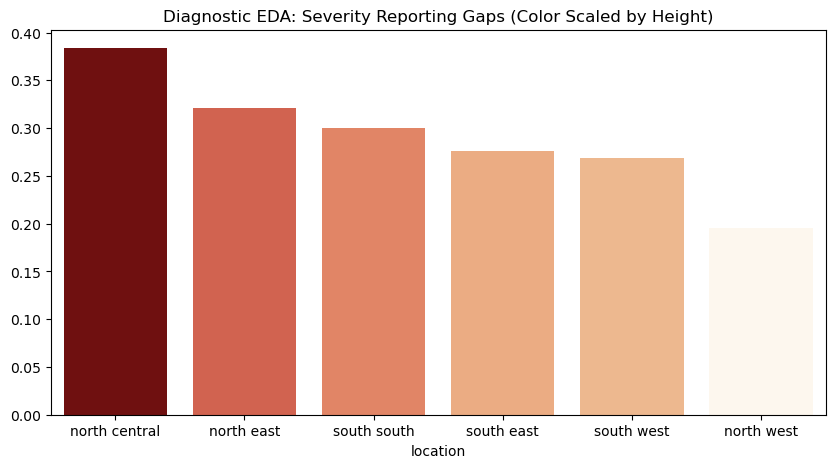

In [22]:
clean_df['severity_missing_flag'] = clean_df['severity_score'].isnull().astype(int)

missing_means = clean_df.groupby('location')['severity_missing_flag'].mean().sort_values(ascending = False)

plt.figure(figsize = (10,5))
sns.barplot(
    x = missing_means.index,
    y = missing_means.values,
    palette = 'OrRd',
    hue = missing_means.values,
    legend = False
)
plt.title('Diagnostic EDA: Severity Reporting Gaps (Color Scaled by Height)')
plt.show()

### Diagnostic EDA: Regional Reporting Quality Summary

**Analysis Overview:**
- **Geopolitical Coverage:** The surveillance data was segmented into the six Nigerian geopolitical zones to identify localized        reporting gaps in the severity_score column.
- **Visual Strategy:** A sequential 'OrRd' (Orange-to-Red) palette was mapped directly to the bar heights. This ensures that           regions with higher missingness, such as North Central, are visually flagged as high-uncertainty areas. 
   
**Key Observations:**

- **Reporting Gaps:** Missingness proportions range from approximately 18% (North West) to 38% (North Central).
- **Threshold Validation:** All zones remain below the 40% Critical Threshold, suggesting that the available data is still             representative enough for regional trend analysis.
- **Visual Interpretation:** The bar height represents the exact proportion of missingness, while the color weight (darker red)        highlights the regions requiring the most urgent data quality interventions.
   
**Clinical Data Strategy:**

- **No Imputation:** In strict adherence to established project constraints, clinical median imputation was not performed to           mitigate missing values.
- **Data Integrity:** By maintaining NaN (Missing) values, we avoid the risk of "smoothing over" regional crises with artificial       averages, ensuring the dashboard reflects only verified clinical reports.
- **Traceability:** This decision ensures that the subsequent Domain Deduplication step operates on raw, untampered evidence .

**Next Step:**
• We will now proceed to the Grouping (Second Deduplication) to arrive at a lower row number by collapsing multiple daily reports into unique patient cases.

### Second Deduplication check
- To check if any patient ID appears more than once
- To count how many reports per patient
- To check if the same patient has severity_score on the same day

In [15]:
patient_id_multiple_occurence = clean_df['patient_id'].duplicated().any()
print(f"Are there multiple entries for the same patient? {patient_id_multiple_occurence}")

report_counts = clean_df['patient_id'].value_counts()
print(report_counts)

same_day_check = clean_df.duplicated(subset = ['patient_id', 'collection_date'], keep = False)
print(f"Patient with multiple entries on the same day: {same_day_check.sum()}")

Are there multiple entries for the same patient? True
patient_id
289    9
198    8
153    7
203    7
147    7
      ..
146    1
118    1
122    1
133    1
115    1
Name: count, Length: 180, dtype: int64
Patient with multiple entries on the same day: 42


### Domian Deduplication (The Grouping)

The focus of this specific grouping is to ensure ***one row = one unique patient case per day***

We group by Patient, Date, and Pathogen.
This collapses 42 duplicate entries into unique Pathogen-Cases

In [28]:
grouped_df = (
clean_df.groupby(['patient_id', 'collection_date', 'pathogen']).agg({
    'location': 'first',
    'age': 'mean',
    'severity_score': 'max',
    'severity_missing_flag': 'min'
})).reset_index()

grouped_df['age'] = grouped_df['age'].round().astype(int)

print(f"Total Raw Reports: {len(clean_df)}")
print(f"Total Unique Pathogen-Cases: {len(grouped_df)}")
print(f"Reduction achieved: {len(clean_df) - len(grouped_df)} rows")

Total Raw Reports: 500
Total Unique Pathogen-Cases: 491
Reduction achieved: 9 rows


In [29]:
check = grouped_df.duplicated(subset = ['patient_id', 'collection_date', 'pathogen']).sum()
print(f"Remaining identical pathogen duplicates: {check}")

Remaining identical pathogen duplicates: 0


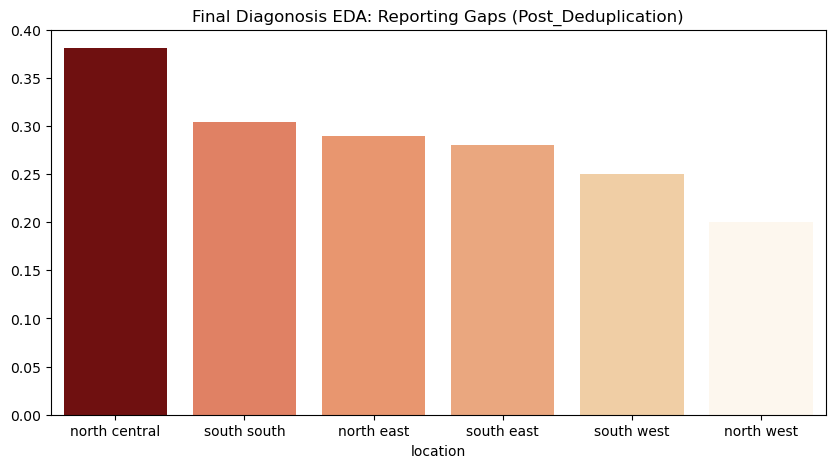

In [30]:
missing_means = grouped_df.groupby('location')['severity_score'].apply(lambda x: x.isnull().mean()).sort_values(ascending = False)

plt.figure(figsize = (10,5))
sns.barplot(
    x = missing_means.index,
    y = missing_means.values,
    palette = 'OrRd',
    hue = missing_means.values,
    legend = False
)

plt.title('Final Diagonosis EDA: Reporting Gaps (Post_Deduplication)')
plt.show()

In [31]:
print(f"--- Final Data Audit ---")
nc_raw = clean_df[clean_df['location'] == 'north central']['severity_score'].isnull().mean()
nc_final = grouped_df[grouped_df['location'] == 'north central']['severity_score'].isnull().mean()

print(f"\nNorth Central Missingness (Raw): {nc_raw:.2%}")
print(f"North Central Missingness (Grouped): {nc_final:.2%}")

--- Final Data Audit ---

North Central Missingness (Raw): 38.37%
North Central Missingness (Grouped): 38.10%


### Observation on Post-Deduplication EDA: 

While the domain deduplication reduced the total record count by 9 rows (1.8%), there was no statistically significant shift in regional missingness proportions. This confirms that reporting gaps are consistent across both raw logs and unique cases, and the 38% gap in North Central is a systemic issue rather than an artifact of duplicate entries.

### Data Quality Discovery: ID Collisions & Demographic Variance
During the verification of the 491 unique cases, we observed instances of `patient_id` reuse across different locations and age groups (e.g., ID 116 and 117). 

**Key Findings:**
* **ID Collisions**: Instances where the same ID refers to different individuals (e.g., an infant in the North West vs. an adult in the South West). 
* **Demographic Averaging**: In cases where the same patient had multiple reports on the same day with slight age discrepancies, our grouping logic calculated a `mean` age (resulting in float values like 67.5 which was converted back to integer).
* **Handling Strategy**: By using a **Composite Grouping Key** (ID + Date + Pathogen), we successfully preserved these as distinct clinical events. This prevents the accidental deletion of infant records or co-infections that happen to share an administrative ID.

**Implication for EDA**: When analyzing age-based trends, we must treat these as unique clinical encounters. The presence of 'Age 0' is confirmed as valid neonatal/infant surveillance data.

## Domain Deduplication: Pathogen-Aware Grouping (Summary)

**Objectives & Results**
To transition from a log of raw reports to a high-integrity dataset of unique clinical cases, we performed a **Domain Deduplication**. This process resulted in a reduction from **500 raw reports** to **491 unique pathogen cases**.

**Grouping Logic (Pathogen-Aware)**
The data was grouped by `patient_id`, `collection_date`, and `pathogen`. This strategy ensures:
* **Co-infection Preservation**: Different pathogens for the same patient on the same day remain as distinct cases .
* **Redundancy Filter**: Multiple daily logs for the same pathogen—including standardized **"Unknown"** entries—were collapsed into a single representative case.
* **Severity Capture**: We utilized the `.max()` aggregate for `severity_score` to record the peak clinical state.

**Handling of "Unknown" Pathogens**
* **Rationale**: "Unknown" pathogens were intentionally preserved rather than imputed to maintain the integrity of the surveillance signal.
* **Clinical Significance**: In a Nigerian public health context, these entries may represent diagnostic bottlenecks or emerging threats. Preserving them ensures the final dashboard provides an honest assessment of laboratory testing capacity.
* **Constraint Adherence**: This approach aligns with our **No-Imputation Rule**, avoiding the creation of "artificial" diagnoses.

In [33]:
grouped_df.to_csv('../data/cleaned/outbreak_surveillance_clean_data.csv', index = False)